In [2]:
import tensorflow as tf
import os
import numpy as np
import matplotlib.pyplot as plt
import keras # For model.history access
import tensorflow_hub as hub # If you used a hub model, though ConvNeXt is Keras Apps
import warnings
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, accuracy_score

warnings.filterwarnings("ignore")
tf.compat.v1.logging.set_verbosity(tf.compat.v1.logging.ERROR) # Suppress TensorFlow warnings
print("Essential imports completed.")

Essential imports completed.


In [3]:
print("Checking for GPU availability...")
print("TensorFlow Version:", tf.__version__)
num_gpus = len(tf.config.list_physical_devices('GPU'))
print("Num GPUs Available: ", num_gpus)
print(tf.config.list_physical_devices(device_type=None))

if num_gpus == 0:
    print("\nWARNING: No GPU detected! Please go to Runtime -> Change runtime type -> Hardware accelerator -> Select 'T4 GPU' (or similar) -> Save, then run ALL cells from the beginning again.")
else:
    print("\nGPU detected. Proceeding to next step.")

Checking for GPU availability...
TensorFlow Version: 2.18.0
Num GPUs Available:  0
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]



In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import tensorflow as tf
import os

# --- Configuration ---
image_size = (224, 224)
batch_size = 32 # <--- Reduced batch size to 32 to fix GPU OOM
seed = 123 # For reproducible split

# Base directory where your 60 food type folders are located
base_dir = '/content/drive/MyDrive/DeshiFood_60' # Confirm this path is correct based on your previous check

# --- Load and Split Dataset ---
print("Loading and splitting dataset...")

# Create training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=image_size,
    interpolation='bicubic',
    batch_size=batch_size,
    shuffle=True,
    validation_split=0.2, # Use 20% of data for validation + test
    subset='training',
    seed=seed
)

# Create validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    base_dir,
    labels='inferred',
    label_mode='categorical',
    image_size=image_size,
    interpolation='bicubic',
    batch_size=batch_size,
    shuffle=False, # No need to shuffle validation data
    validation_split=0.2,
    subset='validation',
    seed=seed
)

# Further split the validation dataset into validation and test sets
# Let's use 50% of the 'validation_split' for actual validation, and the other 50% for test
# So, 10% of total data for validation, 10% for test
val_batches = tf.data.experimental.cardinality(val_ds).numpy()
val_ds_split = val_ds.take(val_batches // 2)
test_ds = val_ds.skip(val_batches // 2)

# --- Get Class Names ---
class_names = train_ds.class_names
print(f"Detected {len(class_names)} classes: {class_names}")

print(f"\nDataset loaded and split:")
print(f"Training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Validation batches: {tf.data.experimental.cardinality(val_ds_split).numpy()}")
print(f"Test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

# Assign the correctly split validation dataset back to val_ds for consistency in training calls
val_ds = val_ds_split

Loading and splitting dataset...
Found 7912 files belonging to 60 classes.
Using 6330 files for training.
Found 7912 files belonging to 60 classes.
Using 1582 files for validation.
Detected 60 classes: ['Alu Bhorta', 'Alu_Vaji', 'Begun Bhaja', 'Begun Bhorta', 'Beguni', 'Biriyani', 'Boiled_egg', 'Borhani', 'Burger', 'Cake', 'Chicken_Grill', 'Chicken_curry', 'Chicken_wings', 'Chingri bhuna', 'Chitoi  Pitha', 'Chocolate_cake', 'Dal', 'Dal Puri', 'Doi', 'Falooda', 'Fish Bhuna_Mach Bhuna', 'French_fries', 'Fried chicken_Murg Bhaja', 'Fried fish_Mach Bhaja', 'Fried_rice', 'Fuchka', 'Hilsha_Fish', 'Jalebi', 'Jorda', 'Kacchi', 'Khichuri', 'Korola_Vaji', 'Lal_shak_Vaji', 'Meat Curry', 'Misti', 'Mixed vegetable', 'Momo', 'Nan Ruti', 'Noodles', 'Parata', 'Payesh_Firni', 'Plain_Rice', 'Rosogolla', 'Salad', 'Sandwich', 'Shak_Vaji', 'Shawarma', 'Shemai', 'Shik_kabab', 'Singgara', 'Sondesh', 'Vapa Pitha', 'cheesecake', 'cup_cakes', 'haleem', 'ice_cream', 'kebab_Gosht Kebab', 'omelette', 'pizza', 'poa

In [6]:
from tensorflow.keras.applications import ConvNeXtTiny
from tensorflow.keras import layers

# Define the input shape required by ConvNeXtTiny
IMG_SHAPE = (224, 224, 3) # (height, width, channels)

# Create the base model from the ConvNeXtTiny pre-trained on ImageNet
base_model = ConvNeXtTiny(input_shape=IMG_SHAPE,
                          include_top=False, # Do not include the ImageNet classification head
                          weights='imagenet') # Use weights pre-trained on ImageNet

# Set the base model's layers to be trainable for fine-tuning
# This will allow the model to adapt to your specific food images
base_model.trainable = True

# Add a GlobalAveragePooling2D layer to flatten the output of the base model
# This prepares the features for the final classification layer
global_average_layer = layers.GlobalAveragePooling2D()

print("ConvNeXtTiny base model defined and set to trainable.")
# You can optionally uncomment the line below to see the summary of the base model
# base_model.summary()

111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
ConvNeXtTiny base model defined and set to trainable.


In [7]:
import tensorflow as tf
from tensorflow.keras import layers, Sequential

# Define your data augmentation layers
data_augmentation = Sequential([
    layers.RandomFlip("horizontal"),         # Randomly flip images horizontally
    layers.RandomRotation(0.1),              # Randomly rotate images by up to 10% (i.e., 36 degrees)
    layers.RandomZoom(0.1),                  # Randomly zoom in or out by up to 10%
    layers.RandomContrast(0.1),              # Randomly adjust contrast by up to 10%
    layers.RandomBrightness(0.1),            # Randomly adjust brightness by up to 10%
], name="data_augmentation_pipeline")

print("Data augmentation pipeline defined.")

Data augmentation pipeline defined.


In [8]:
from tensorflow.keras import layers, Sequential

# Make sure 'data_augmentation', 'base_model', and 'global_average_layer' are already defined

# Create the new model with augmentation
model_with_augmentation = Sequential([
    data_augmentation,         # Data augmentation pipeline
    base_model,                # ConvNeXtTiny base model
    global_average_layer,      # <--- IMPORTANT: ADD THIS LAYER TO FLATTEN FEATURES
    layers.Dense(len(class_names), activation='softmax') # Final classification layer
], name="convnext_with_augmentation")

# Ensure the base model's layers are trainable for fine-tuning
for layer in base_model.layers:
    layer.trainable = True

# --- NEW LINE TO ADD ---
# Explicitly build the model (or call .summary() which also builds it)
# The input_shape for the Sequential model is the IMG_SHAPE (224, 224, 3)
# We use (None, *IMG_SHAPE) to indicate an unknown batch size
model_with_augmentation.build(input_shape=(None, *IMG_SHAPE))
model_with_augmentation.summary() # Also implicitly builds and shows summary
# --- END NEW LINE TO ADD ---


print("New model 'model_with_augmentation' created with augmentation pipeline (corrected and built).")

Model: "convnext_with_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation_pipeline      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_tiny (Functional)      │ (None, 7, 7, 768)      │    27,820,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 768)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 60)             │        46,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,866,268 (106.30 MB)

 Trainable params: 27,866,268 (106.30 MB)

 Non-trainable params: 0 (0.00 B)

New model 'model_with_augmentation' created with augmentation pipeline (corrected and built).


In [9]:
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.losses import CategoricalCrossentropy

model_with_augmentation.compile(
    optimizer=AdamW(learning_rate=0.001, weight_decay=0.004, beta_1=0.9, beta_2=0.999, epsilon=1e-8),
    loss=CategoricalCrossentropy(),
    metrics=['accuracy']
)

print("Model 'model_with_augmentation' compiled successfully.")

Model 'model_with_augmentation' compiled successfully.


In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import os

# Define the directory for saving augmented model weights
# Using a new subfolder 'augmented_v2' to be absolutely clear and avoid conflicts
output_dir_augmented = "/content/drive/MyDrive/training_weights/augmented_v2"
os.makedirs(output_dir_augmented, exist_ok=True)
print(f"Ensured directory exists: {output_dir_augmented}")

# Redefine Callbacks for the augmented model
reduce_lr_augmented = ReduceLROnPlateau(monitor='val_loss', factor=0.2,
                                         patience=5, min_lr=1e-5)

best_augmented = ModelCheckpoint(filepath=os.path.join(output_dir_augmented, "model_augmented_best_val_accuracy.weights.h5"),
                                 save_weights_only=True,
                                 monitor="val_accuracy",
                                 mode="max",
                                 save_best_only=True)

early_stop_augmented = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True) # Added restore_best_weights=True

print("\nCallbacks for augmented model defined (reduce_lr_augmented, best_augmented, early_stop_augmented).")

Ensured directory exists: /content/drive/MyDrive/training_weights/augmented_v2

Callbacks for augmented model defined (reduce_lr_augmented, best_augmented, early_stop_augmented).


In [11]:
import os

# Define the path to your best saved weights (this must match the filepath in your ModelCheckpoint)
# It should be in the 'augmented_v2' folder we created:
saved_weights_path = os.path.join("/content/drive/MyDrive/training_weights/augmented_v2", "model_augmented_best_val_accuracy.weights.h5")

if os.path.exists(saved_weights_path):
    print(f"Loading weights from: {saved_weights_path}")
    model_with_augmentation.load_weights(saved_weights_path)
    print("Weights loaded successfully. Model is restored to its best performance from previous session.")
else:
    print(f"Error: No saved weights found at {saved_weights_path}. You might need to train from scratch or verify the path.")

# You can optionally evaluate the model after loading weights to confirm its current accuracy
# loss, accuracy = model_with_augmentation.evaluate(val_ds)
# print(f"Model accuracy after loading weights: {accuracy*100:.2f}%")

Loading weights from: /content/drive/MyDrive/training_weights/augmented_v2/model_augmented_best_val_accuracy.weights.h5
Weights loaded successfully. Model is restored to its best performance from previous session.


In [ ]:
# Assuming train_ds and val_ds are already loaded from previous steps and confirmed

print("Starting training of model_with_augmentation...")

history_augmented = model_with_augmentation.fit(
    train_ds,
    epochs=20, # Set a sufficiently high number of epochs, EarlyStopping will manage it
    validation_data=val_ds,
    callbacks=[reduce_lr_augmented, best_augmented, early_stop_augmented]
)

print("\nTraining completed for model_with_augmentation.")

Starting training of model_with_augmentation...
Epoch 1/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 1551s 8s/step - accuracy: 0.8999 - loss: 0.3537 - val_accuracy: 0.9337 - val_loss: 0.2122 - learning_rate: 0.0010
Epoch 2/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.9251 - loss: 0.2666 - val_accuracy: 0.9488 - val_loss: 0.1741 - learning_rate: 0.0010
Epoch 3/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.9311 - loss: 0.2192 - val_accuracy: 0.9187 - val_loss: 0.2267 - learning_rate: 0.0010
Epoch 4/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.9273 - loss: 0.2264 - val_accuracy: 0.9812 - val_loss: 0.0747 - learning_rate: 0.0010
Epoch 5/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.9526 - loss: 0.1402 - val_accuracy: 0.9700 - val_loss: 0.1024 - learning_rate: 0.0010
Epoch 6/20
198/198 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.9543 - loss: 0.1417 - val_accuracy: 0.9538 - val_loss: 0.1721 - learning_rate: 0.0010
Epoch 7/20
198/198 ━━━━━━━━━━━━━━

In [12]:
import os

# Define the path to your best saved weights (this must match the filepath in your ModelCheckpoint)
# This ensures you're evaluating the best version of your model
best_weights_path = os.path.join("/content/drive/MyDrive/training_weights/augmented_v2", "model_augmented_best_val_accuracy.weights.h5")

# Check if the best weights exist and load them
if os.path.exists(best_weights_path):
    print(f"Loading the best saved weights from: {best_weights_path}")
    model_with_augmentation.load_weights(best_weights_path)
    print("Best weights loaded successfully for final evaluation.")
else:
    print(f"WARNING: Best weights not found at {best_weights_path}. Evaluating with current model state.")
    print("This might happen if training was interrupted before a checkpoint was saved,")
    print("or if 'restore_best_weights=True' in EarlyStopping already restored them.")


print("\nEvaluating model on the test dataset...")
test_loss, test_accuracy = model_with_augmentation.evaluate(test_ds)

print(f"\nFinal Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_accuracy*100:.2f}%")

Loading the best saved weights from: /content/drive/MyDrive/training_weights/augmented_v2/model_augmented_best_val_accuracy.weights.h5
Best weights loaded successfully for final evaluation.

Evaluating model on the test dataset...
25/25 ━━━━━━━━━━━━━━━━━━━━ 1484s 54s/step - accuracy: 0.9785 - loss: 0.1044

Final Test Loss: 0.0913
Final Test Accuracy: 97.95%


Parsed training data for 16 epochs.


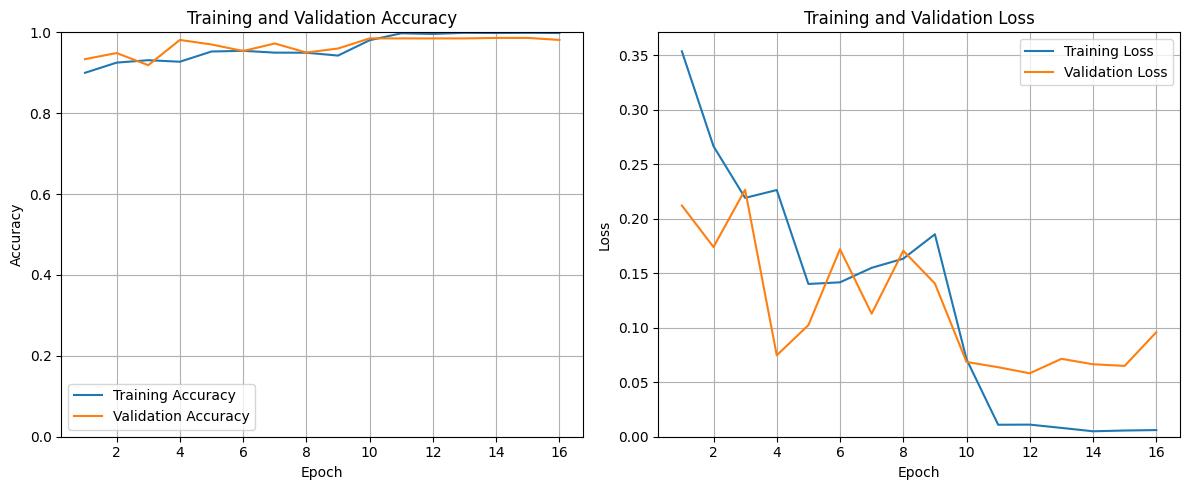

Training history plots generated from provided logs.


In [18]:
import matplotlib.pyplot as plt
import pandas as pd
import re

# IMPORTANT: This 'training_log' string contains the text output from your previous training run.
# It's used here because the 'history_augmented' object from your original training session is no longer in memory.
training_log = """
Starting training of model_with_augmentation...
Epoch 1/20198/198 ━━━━━━━━━━━━━━━━━━━━ 1551s 8s/step - accuracy: 0.8999 - loss: 0.3537 - val_accuracy: 0.9337 - val_loss: 0.2122 - learning_rate: 0.0010
Epoch 2/20198/198 ━━━━━━━━━━━━━━━━━━━━ 268s 1s/step - accuracy: 0.9251 - loss: 0.2666 - val_accuracy: 0.9488 - val_loss: 0.1741 - learning_rate: 0.0010
Epoch 3/20198/198 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.9311 - loss: 0.2192 - val_accuracy: 0.9187 - val_loss: 0.2267 - learning_rate: 0.0010
Epoch 4/20198/198 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.9273 - loss: 0.2264 - val_accuracy: 0.9812 - val_loss: 0.0747 - learning_rate: 0.0010
Epoch 5/20198/198 ━━━━━━━━━━━━━━━━━━━━ 315s 1s/step - accuracy: 0.9526 - loss: 0.1402 - val_accuracy: 0.9700 - val_loss: 0.1024 - learning_rate: 0.0010
Epoch 6/20198/198 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.9543 - loss: 0.1417 - val_accuracy: 0.9538 - val_loss: 0.1721 - learning_rate: 0.0010
Epoch 7/20198/198 ━━━━━━━━━━━━━━━━━━━━ 264s 1s/step - accuracy: 0.9498 - loss: 0.1550 - val_accuracy: 0.9725 - val_loss: 0.1129 - learning_rate: 0.0010
Epoch 8/20198/198 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.9496 - loss: 0.1634 - val_accuracy: 0.9500 - val_loss: 0.1707 - learning_rate: 0.0010
Epoch 9/20198/198 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.9425 - loss: 0.1858 - val_accuracy: 0.9600 - val_loss: 0.1406 - learning_rate: 0.0010
Epoch 10/20198/198 ━━━━━━━━━━━━━━━━━━━━ 271s 1s/step - accuracy: 0.9805 - loss: 0.0711 - val_accuracy: 0.9850 - val_loss: 0.0686 - learning_rate: 2.0000e-04
Epoch 11/20198/198 ━━━━━━━━━━━━━━━━━━━━ 260s 1s/step - accuracy: 0.9976 - loss: 0.0110 - val_accuracy: 0.9850 - val_loss: 0.0638 - learning_rate: 2.0000e-04
Epoch 12/20198/198 ━━━━━━━━━━━━━━━━━━━━ 259s 1s/step - accuracy: 0.9960 - loss: 0.0111 - val_accuracy: 0.9850 - val_loss: 0.0582 - learning_rate: 2.0000e-04
Epoch 13/20198/198 ━━━━━━━━━━━━━━━━━━━━ 255s 1s/step - accuracy: 0.9988 - loss: 0.0081 - val_accuracy: 0.9850 - val_loss: 0.0715 - learning_rate: 2.0000e-04
Epoch 14/20198/198 ━━━━━━━━━━━━━━━━━━━━ 265s 1s/step - accuracy: 0.9983 - loss: 0.0050 - val_accuracy: 0.9862 - val_loss: 0.0665 - learning_rate: 2.0000e-04
Epoch 15/20198/198 ━━━━━━━━━━━━━━━━━━━━ 313s 1s/step - accuracy: 0.9988 - loss: 0.0057 - val_accuracy: 0.9862 - val_loss: 0.0650 - learning_rate: 2.0000e-04
Epoch 16/20198/198 ━━━━━━━━━━━━━━━━━━━━ 256s 1s/step - accuracy: 0.9983 - loss: 0.0061 - val_accuracy: 0.9812 - val_loss: 0.0959 - learning_rate: 2.0000e-04
Epoch 17/20 74/198 ━━━━━━━━━━━━━━━━━━━━ 2:35 1s/step - accuracy: 0.9979 - loss: 0.0053
"""

# Initialize lists to store extracted data
epochs = []
accuracy = []
loss = []
val_accuracy = []
val_loss = []
learning_rate = []

# Regex to find the data in each epoch line
# It looks for patterns like 'accuracy: X.XXXX - loss: X.XXXX - val_accuracy: X.XXXX - val_loss: X.XXXX - learning_rate: X.XXXX'
pattern = r"Epoch (\d+)/\d+.*?accuracy: ([\d.]+) - loss: ([\d.]+) - val_accuracy: ([\d.]+) - val_loss: ([\d.]+) - learning_rate: ([\deE.-]+)"

# Iterate over each line and extract data
for line in training_log.split('\n'):
    match = re.search(pattern, line)
    if match:
        epochs.append(int(match.group(1)))
        accuracy.append(float(match.group(2)))
        loss.append(float(match.group(3)))
        val_accuracy.append(float(match.group(4)))
        val_loss.append(float(match.group(5)))
        learning_rate.append(float(match.group(6)))

# Create a dictionary similar to history.history
parsed_history = {
    'accuracy': accuracy,
    'loss': loss,
    'val_accuracy': val_accuracy,
    'val_loss': val_loss,
    'lr': learning_rate # Often learning_rate is stored as 'lr'
}

# Convert to DataFrame for easier plotting
hist_df = pd.DataFrame(parsed_history)

print("Parsed training data for", len(hist_df), "epochs.")

# Plot training and validation accuracy
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(hist_df.index + 1, hist_df['accuracy'], label='Training Accuracy')
plt.plot(hist_df.index + 1, hist_df['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.ylim(0.0, 1.0) # Set y-axis limit for accuracy

# Plot training and validation loss
plt.subplot(1, 2, 2)
plt.plot(hist_df.index + 1, hist_df['loss'], label='Training Loss')
plt.plot(hist_df.index + 1, hist_df['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.ylim(bottom=0.0) # Set y-axis limit for loss to start from 0

plt.tight_layout()
plt.show()

print("Training history plots generated from provided logs.")

Generating predictions for the test dataset...
1/1 ━━━━━━━━━━━━━━━━━━━━ 61s 61s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 55s 55s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 55s 55s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 58s 58s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 57s 57s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 55s 55s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 55s 55s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 55s 55s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 53s 53s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 56s 56s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 53s 53s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 55s 55s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 55s 55s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 55s 55s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 56s 56s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 53s 53s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 54s 54s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 56s 56s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 53s 53s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 57s 57s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 53s 53s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 57s 57s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 55s 55s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 53s 53s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 28s 28s/step
Pre

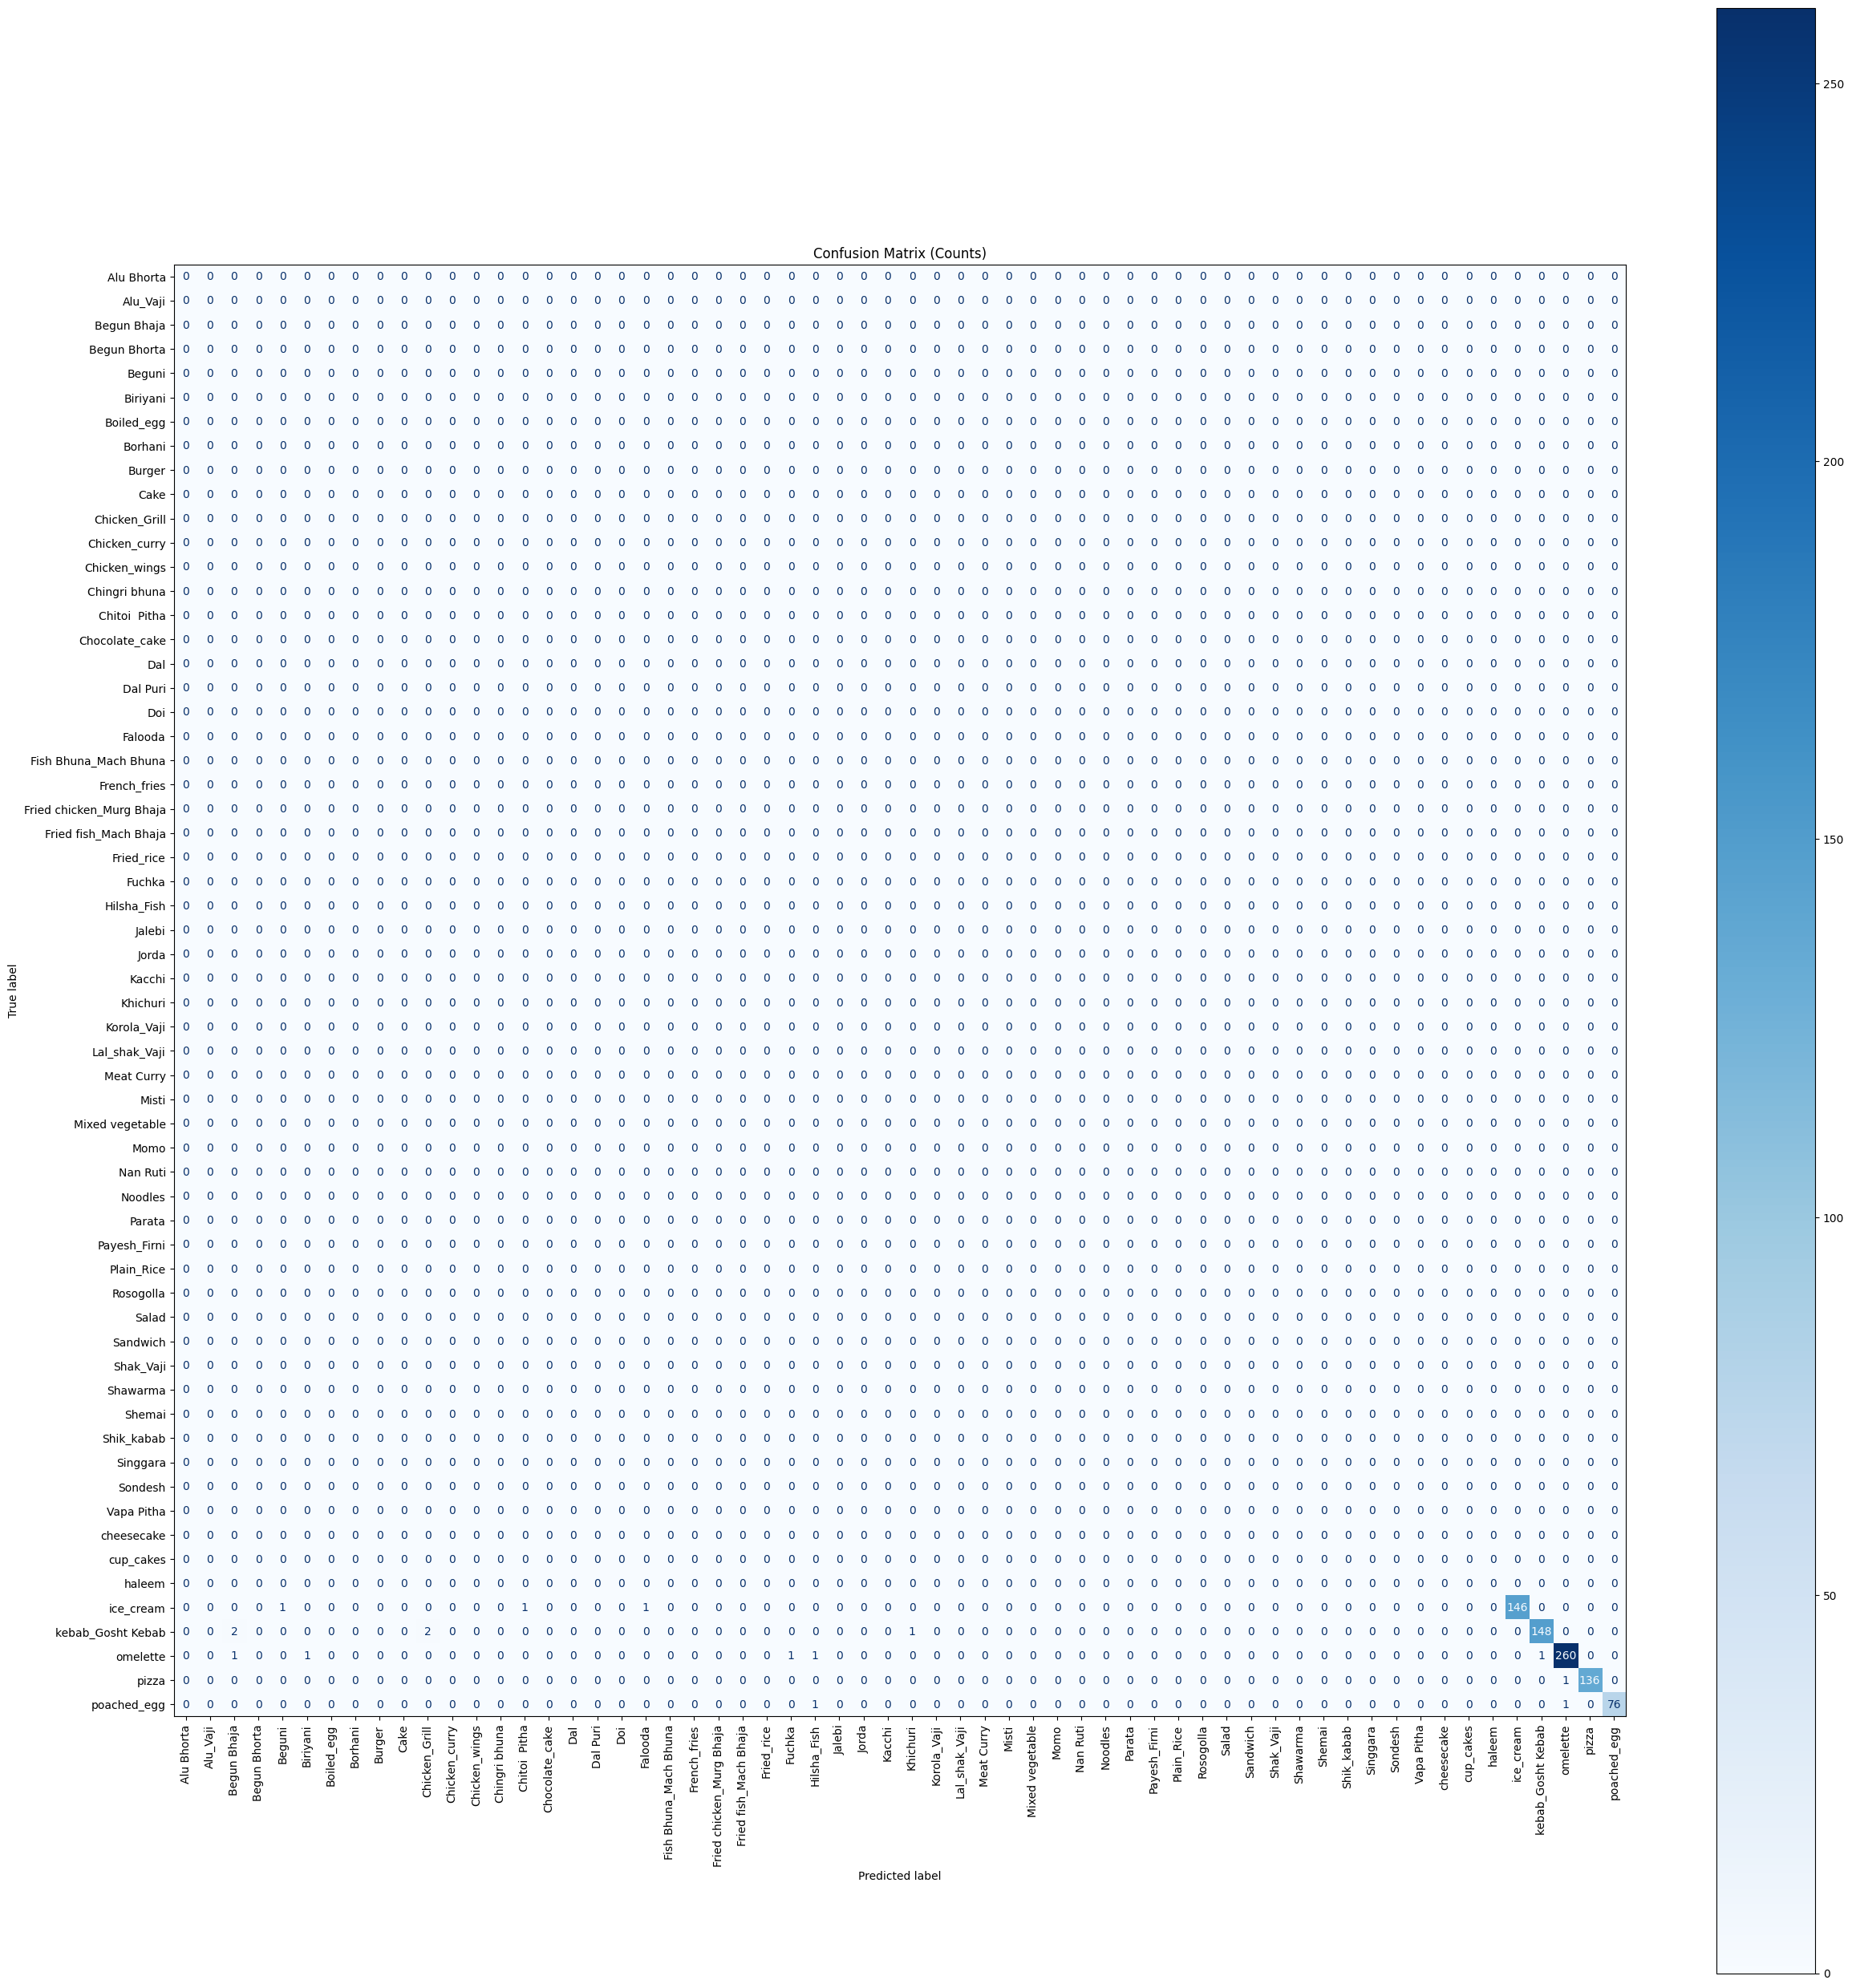

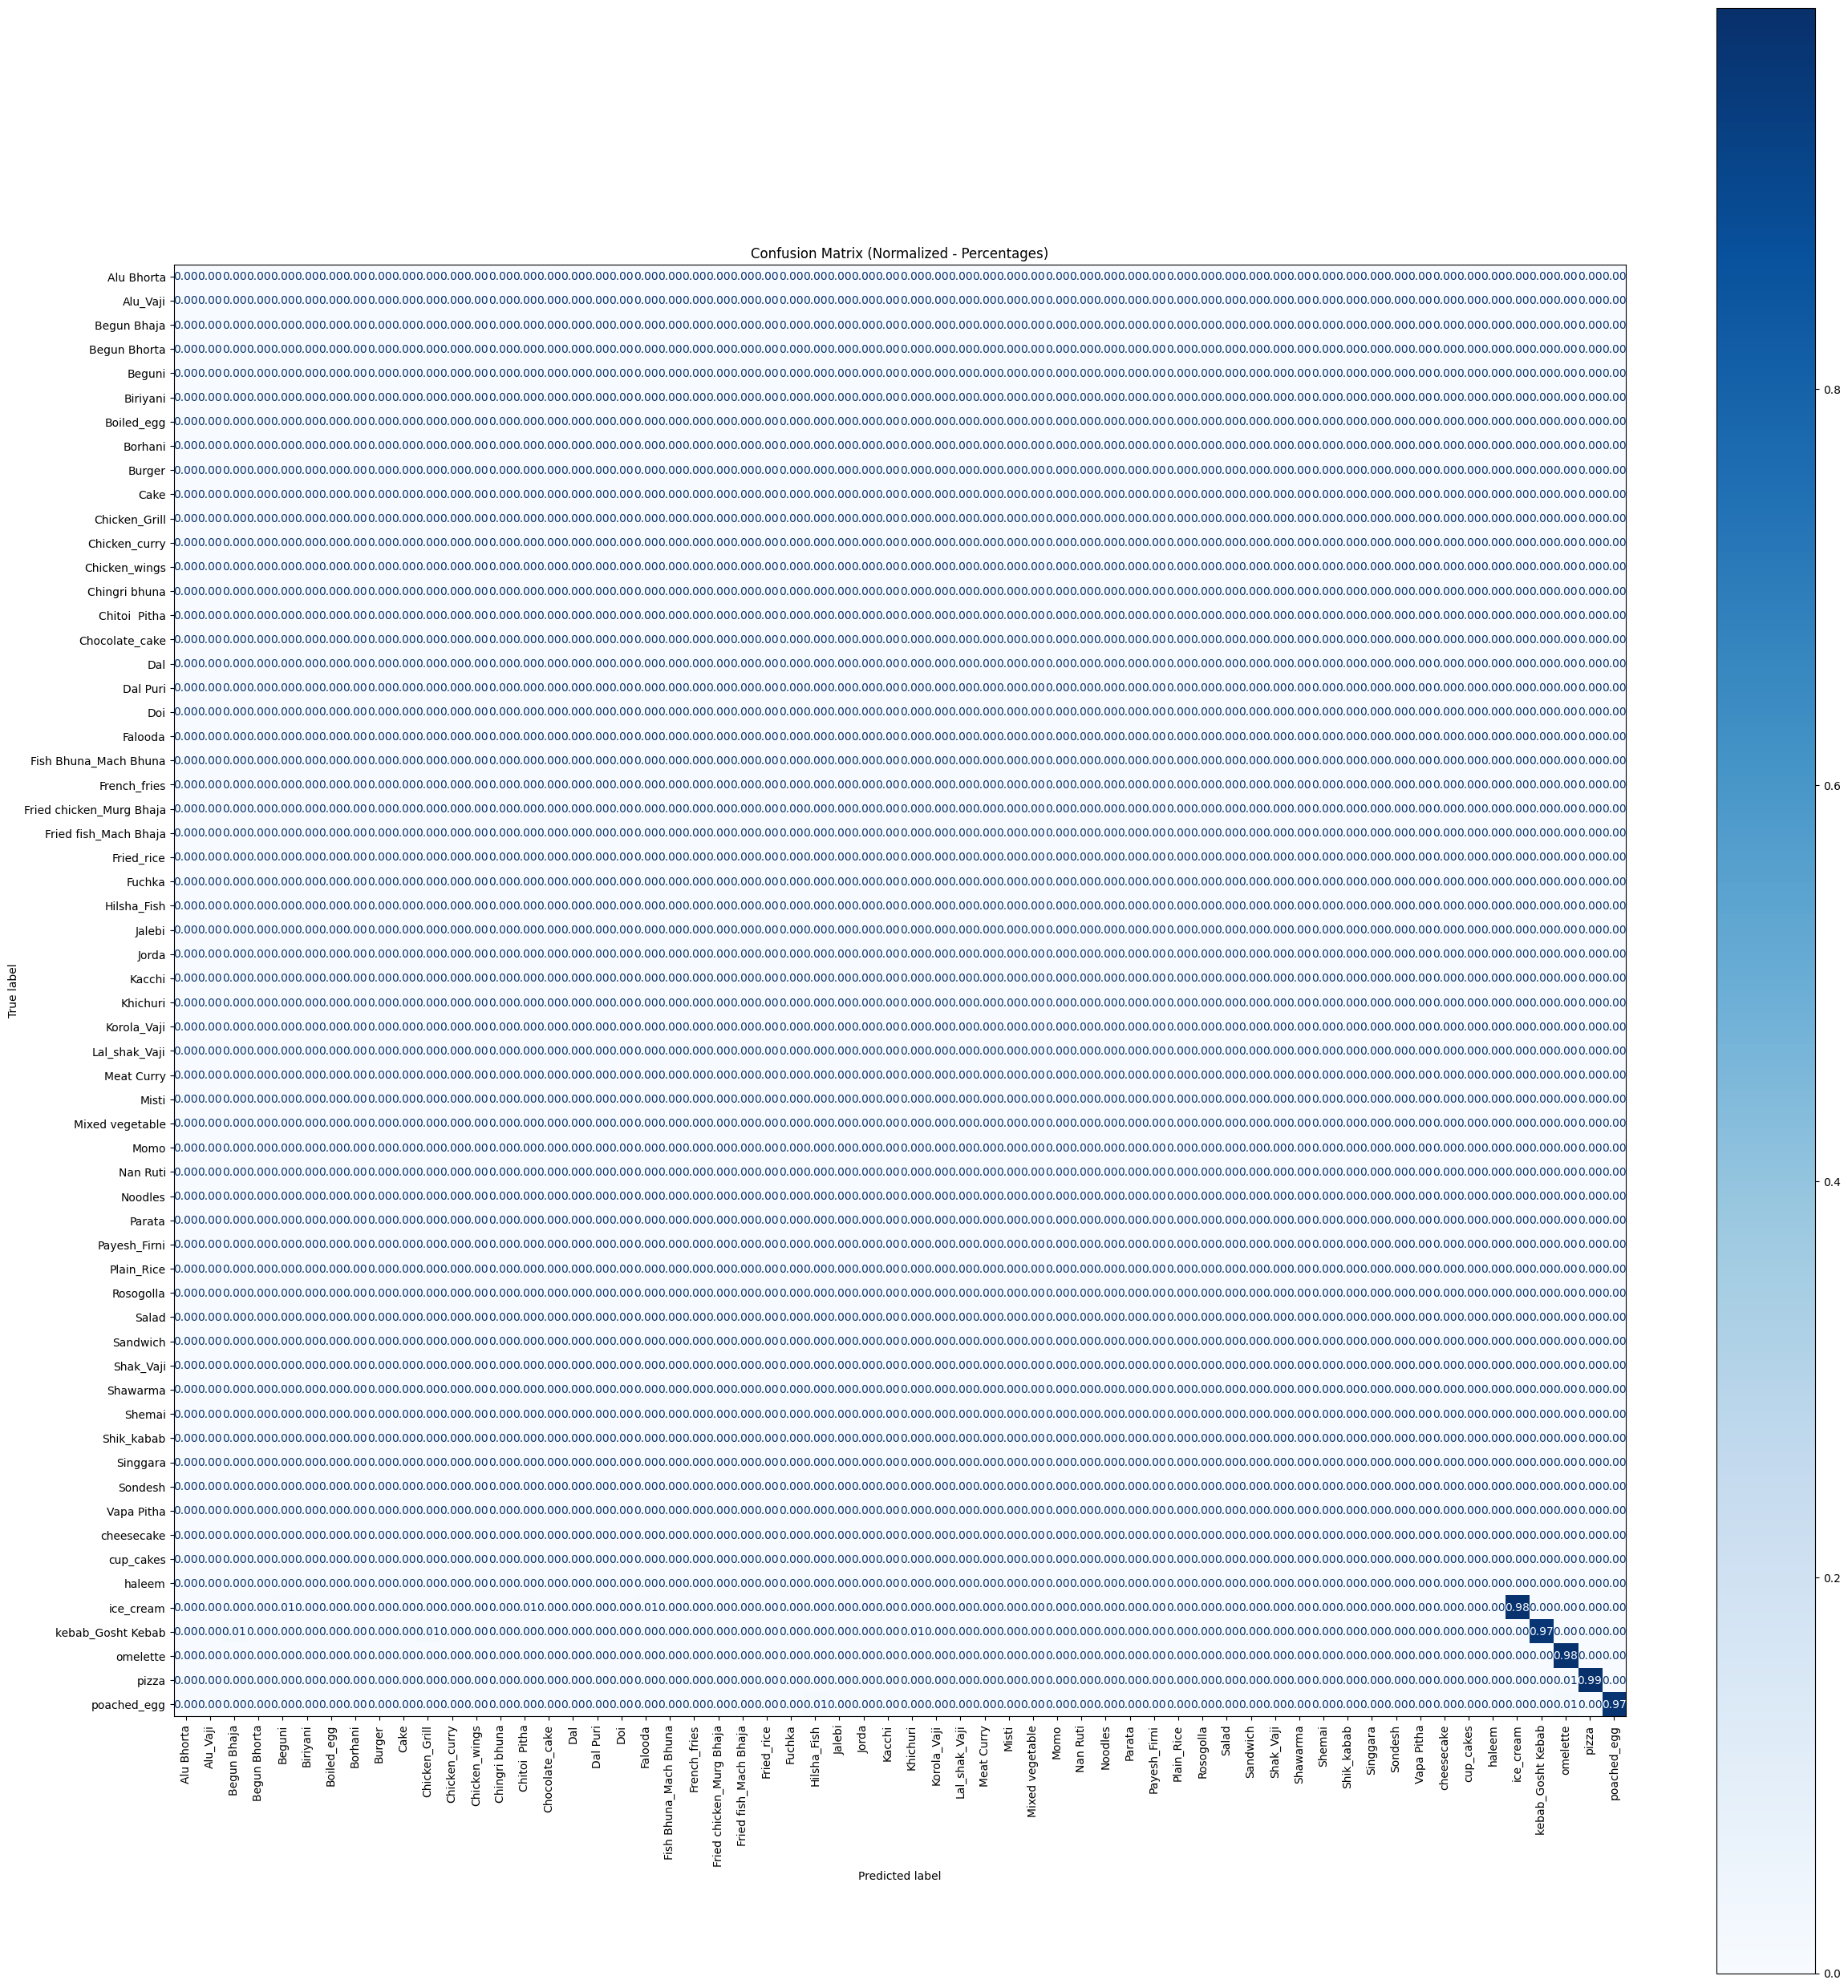


Classification report and confusion matrices generated.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report
import tensorflow as tf # Required for tf.argmax and dataset iteration

# Ensure model_with_augmentation, test_ds, and class_names are defined from your previous steps.
# For example:
# model_with_augmentation = tf.keras.models.load_model('path_to_your_model') # Or build it and load weights
# test_ds = tf.data.Dataset.from_tensor_slices(...) # Your test dataset
# class_names = [...] # Your list of 60 class names

# --- START: Previous code to generate y_true, y_pred, y_pred_probs ---
print("Generating predictions for the test dataset...")

y_true = []
y_pred_probs = []

# Ensure test_ds is reset to its beginning for consistent iteration
# This line will recreate the iterator so it starts from the first batch
# test_ds_iter = iter(test_ds) # This explicit iterator might not be necessary if iterating directly on test_ds works fine.

for images, labels in test_ds:
    y_true.extend(tf.argmax(labels, axis=1).numpy()) # Convert one-hot labels to class indices
    y_pred_probs.extend(model_with_augmentation.predict(images)) # Get predictions

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1) # Convert probabilities to class indices

print("Predictions generated.")
# --- END: Previous code to generate y_true, y_pred, y_pred_probs ---


# --- Classification Report ---
print("\n--- Classification Report ---")
# Define all possible labels (0 to 59 for 60 classes)
all_possible_labels = np.arange(len(class_names))
print(classification_report(y_true, y_pred, target_names=class_names, labels=all_possible_labels, zero_division=0))


# --- CORRECTED Confusion Matrix Plotting ---
print("\n--- Confusion Matrix ---")

# 1. Calculate the raw confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=all_possible_labels)

# 2. Plot the RAW Confusion Matrix (Counts)
fig, ax = plt.subplots(figsize=(25, 25)) # Increased size for better readability
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
# Display counts (d format)
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='vertical', values_format='d')
plt.title('Confusion Matrix (Counts)')
plt.tight_layout()
plt.show()

# 3. Plot the NORMALIZED Confusion Matrix (Percentages)
# Calculate the normalized confusion matrix manually
# Add a small epsilon to avoid division by zero for classes with zero true samples
epsilon = 1e-10
cm_normalized = cm.astype('float') / (cm.sum(axis=1)[:, np.newaxis] + epsilon)
# No need for isnan check if epsilon is used, as it handles division by zero

fig_norm, ax_norm = plt.subplots(figsize=(25, 25)) # Increased size
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
# Use values_format='.2f' to show percentages with 2 decimal places
disp_norm.plot(cmap=plt.cm.Blues, ax=ax_norm, xticks_rotation='vertical', values_format='.2f')
plt.title('Confusion Matrix (Normalized - Percentages)')
plt.tight_layout()
plt.show()

print("\nClassification report and confusion matrices generated.")